# SHAP & Model Interpretability Analysis
**Project:** Biological Age Predictor  
**Data:** NHANES August 2021–August 2023 Held-Out Test Set ($N = 1,199$, Age 18–79)  
**Goal:** Apply SHAP (SHapley Additive exPlanations) values to explain the trained XGBoost model, rank global biomarker drivers of biological aging, identify non-linear clinical inflection thresholds, and generate individual biological age gap waterfall explanations.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Robustly resolve project root and add 'src' to sys.path
current_dir = Path.cwd()
project_root = current_dir if (current_dir / 'src').exists() else current_dir.parent
src_dir = project_root / 'src'
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

import shap
from explainability import load_model_and_data, compute_shap_explanation, get_global_feature_importance

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Inter'
plt.rcParams['figure.dpi'] = 120

C:\Users\Pc Bridge\Desktop\andrew\projects\biological-age-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## Global Feature Importance & SHAP Ranking

We load the trained XGBoost model (`models/final_model.pkl`) and compute SHAP values for all 1,199 participants in the test set using `shap.TreeExplainer`.

Each SHAP value represents the exact marginal contribution (in years) of a specific biomarker toward increasing or decreasing an individual's predicted biological age relative to the population baseline.

In [2]:
model_path = project_root / 'models' / 'final_model.pkl'
test_path = project_root / 'data' / 'processed' / 'test_data.csv'
train_path = project_root / 'data' / 'processed' / 'train_data.csv'

model, X_test, y_test, test_df = load_model_and_data(model_path, test_path, train_path)
shap_exp, explainer = compute_shap_explanation(model, X_test)
importance_df = get_global_feature_importance(shap_exp, list(X_test.columns))

display(importance_df.head(10))

2026-08-20 14:48:57,419 - INFO - Loading trained model from C:\Users\Pc Bridge\Desktop\andrew\projects\biological-age-predictor\models\final_model.pkl...


C:\Users\Pc Bridge\Desktop\andrew\projects\biological-age-predictor\src\explainability.py:53: UserWarning: [14:48:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  model = pickle.load(f)


2026-08-20 14:48:57,591 - INFO - Extracted feature matrices: X_train = (4796, 27), y_train = (4796,), X_test = (1199, 27), y_test = (1199,) across 27 features.


2026-08-20 14:48:57,592 - INFO - Computing SHAP values across 1199 samples and 27 features using TreeExplainer...


2026-08-20 14:48:57,767 - INFO - SHAP values computed successfully.


2026-08-20 14:48:57,775 - INFO - Top 5 global biological age drivers:
              feature  mean_abs_shap_years
            log_LBXGH             5.374131
                 WHtR             3.053284
             LBXMCVSI             2.792656
smoking_Former Smoker             1.604398
           log_LBXSCR             1.490568


,feature,mean_abs_shap_years
0,log_LBXGH,5.374131
1,WHtR,3.053284
2,LBXMCVSI,2.792656
3,smoking_Former Smoker,1.604398
4,log_LBXSCR,1.490568
5,LBXPLTSI,1.369457
6,BMXWT,1.234744
7,BMXBMI,1.218768
8,INDFMPIR,1.113894
9,log_LBXSGL,1.061339


### SHAP Beeswarm Summary Plot

The summary plot below ranks biomarkers by mean absolute impact (vertical axis) and shows directionality:
- **Red points (High Feature Values):** Points to the right (positive SHAP value) indicate that higher biomarker levels accelerate biological age prediction.
- **Blue points (Low Feature Values):** Points to the left indicate lower biomarker levels decrease biological age prediction.

2026-08-20 14:48:58,019 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,026 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,028 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,029 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,031 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

2026-08-20 14:48:58,752 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,753 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,754 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,754 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,756 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


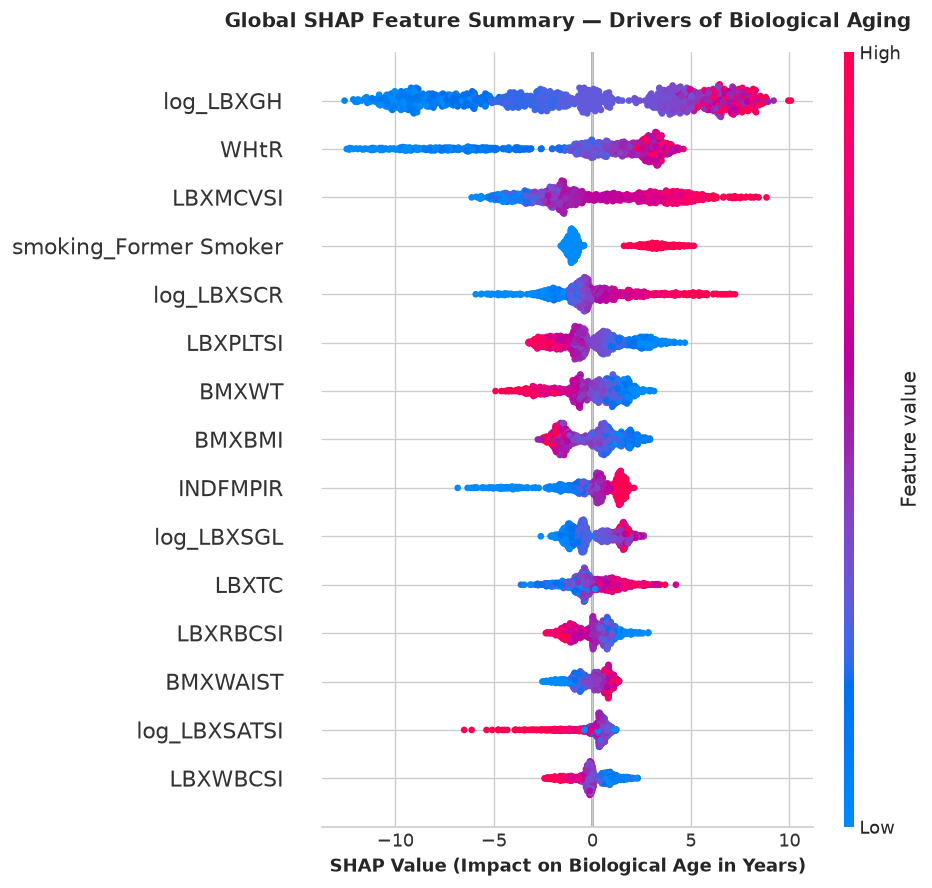

In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_exp.values, X_test, max_display=15, show=False)
plt.title('Global SHAP Feature Summary — Drivers of Biological Aging', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('SHAP Value (Impact on Biological Age in Years)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Non-Linear Inflection Thresholds (SHAP Dependence)

SHAP dependence plots reveal non-linear physiological risk thresholds — showing exactly where a biomarker value transitions from protective to biological age accelerating.

2026-08-20 14:48:58,854 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,859 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,861 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,861 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:58,863 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

2026-08-20 14:48:59,957 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:59,958 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:59,959 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:59,967 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:59,968 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


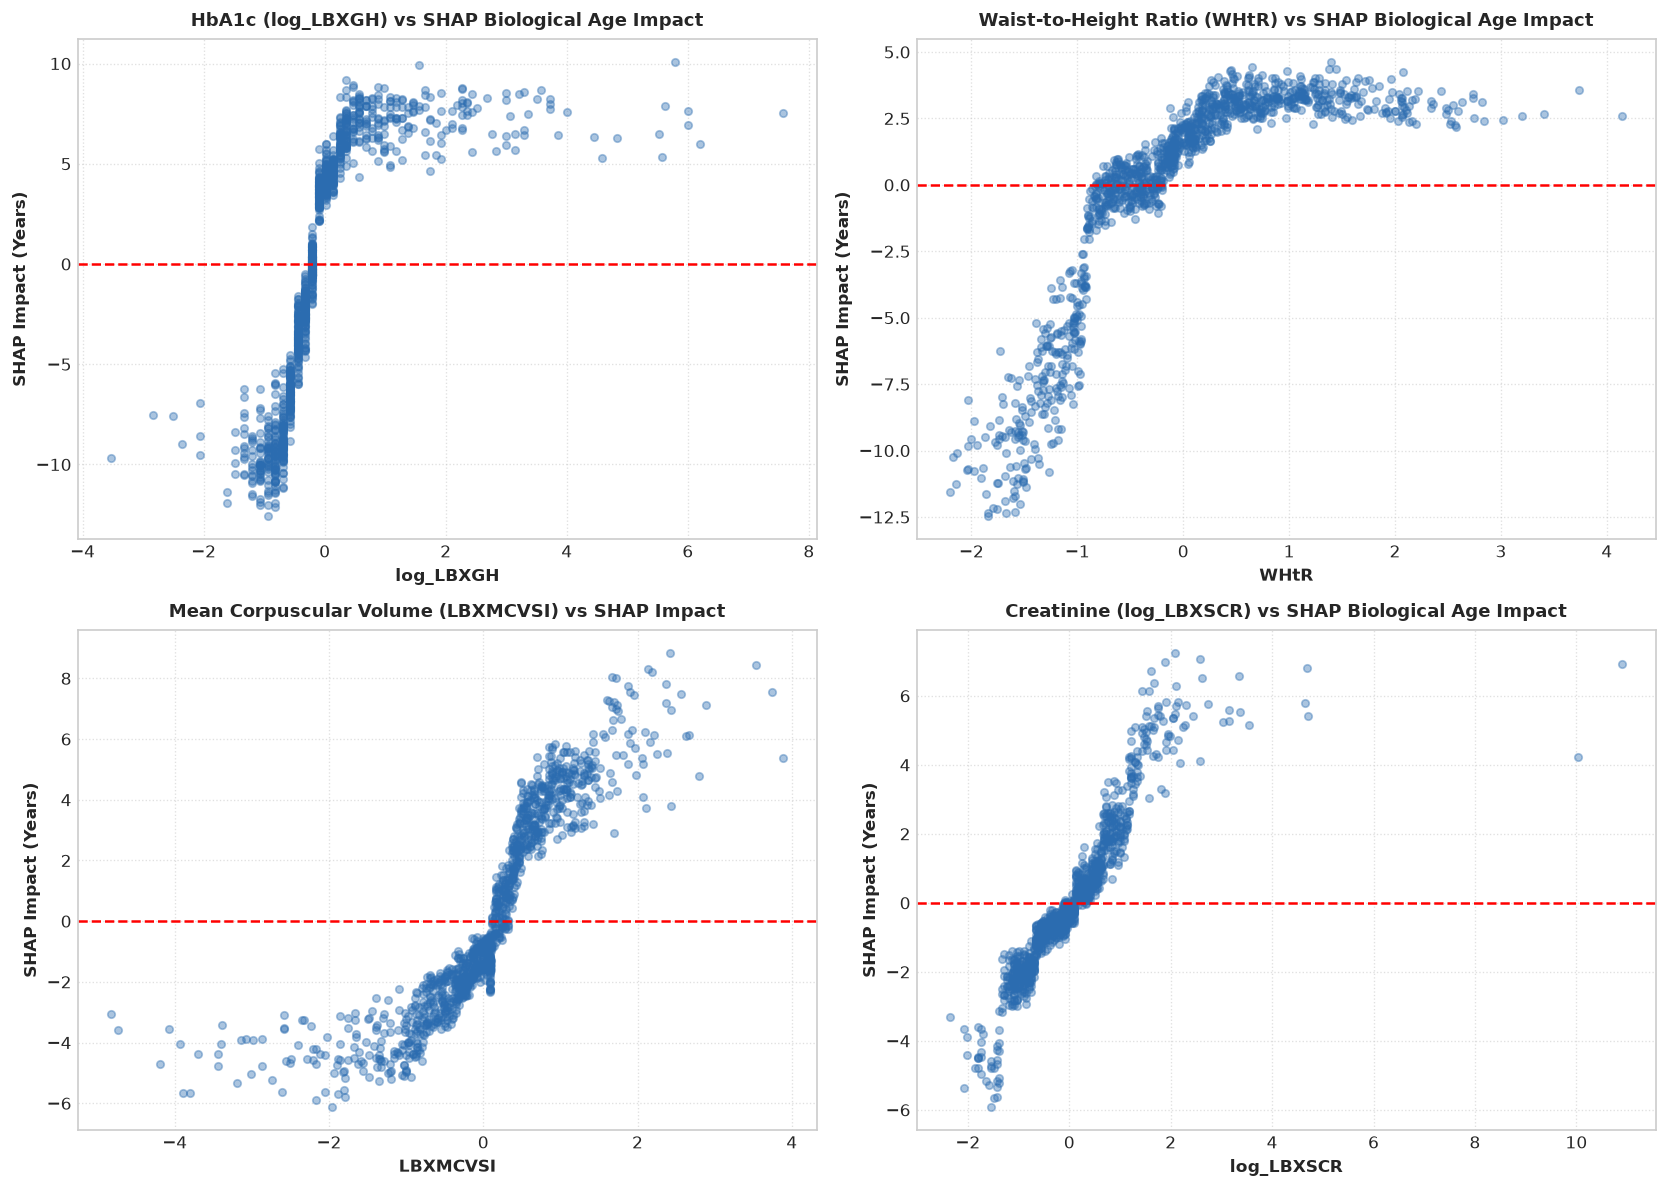

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 4 key features to plot dependence
dep_features = ['log_LBXGH', 'WHtR', 'LBXMCVSI', 'log_LBXSCR']
titles = [
    'HbA1c (log_LBXGH) vs SHAP Biological Age Impact',
    'Waist-to-Height Ratio (WHtR) vs SHAP Biological Age Impact',
    'Mean Corpuscular Volume (LBXMCVSI) vs SHAP Impact',
    'Creatinine (log_LBXSCR) vs SHAP Biological Age Impact'
]

for idx, feat in enumerate(dep_features):
    ax = axes[idx // 2, idx % 2]
    feat_idx = list(X_test.columns).index(feat)
    
    ax.scatter(X_test[feat], shap_exp.values[:, feat_idx], alpha=0.4, color='#2B6CB0', s=20)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(titles[idx], fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('SHAP Impact (Years)', fontsize=10, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---

## Individual Participant Case Studies (Waterfall Explanations)

We examine individual biological age gap explanations ($\Delta = \text{Predicted Age} - \text{Actual Age}$) for two contrasting participants:
1. **Participant A:** Accelerated Biological Ager (Positive Gap $\Delta > +10$ years).
2. **Participant B:** Youthful / Decelerated Biological Ager (Negative Gap $\Delta < -10$ years).

2026-08-20 14:49:00,094 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,095 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,098 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,098 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,102 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

2026-08-20 14:49:00,967 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,969 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,969 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,971 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:49:00,971 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


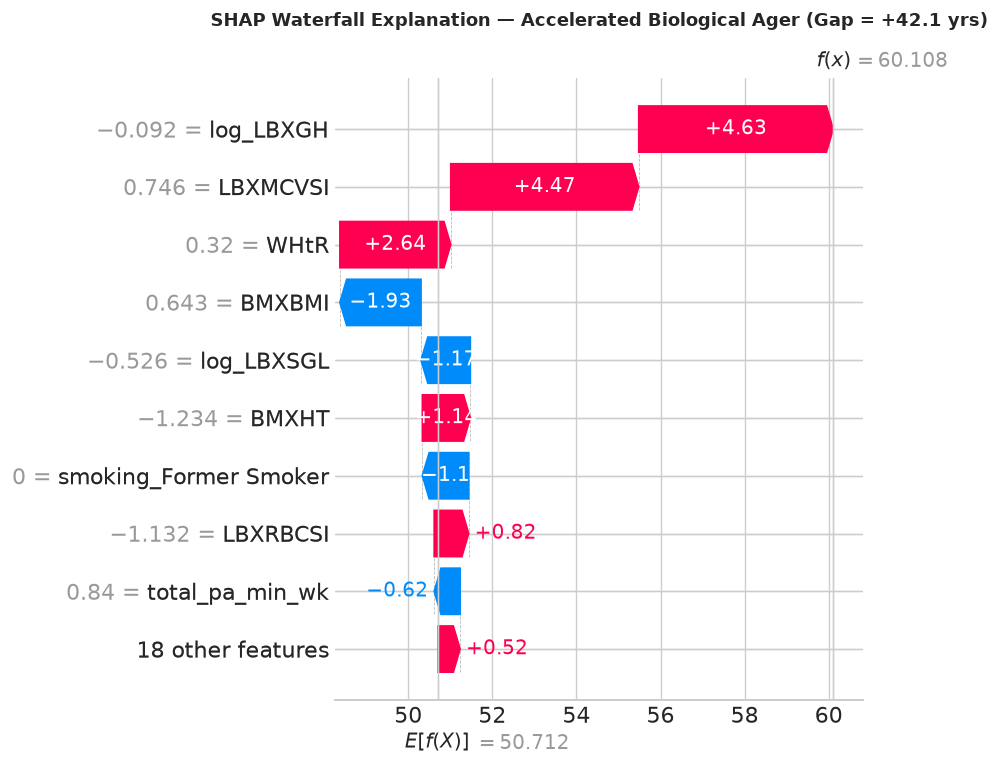

In [5]:
test_results = test_df.copy()
test_results['predicted_age'] = model.predict(X_test)
test_results['bio_age_gap'] = test_results['predicted_age'] - test_results['RIDAGEYR']

# Select representative accelerated ager and decelerated ager
accel_idx = test_results['bio_age_gap'].idxmax()
decel_idx = test_results['bio_age_gap'].idxmin()

print(f"=== Accelerated Ager Case Study (Sample Index {accel_idx}) ===")
print(f"Actual Age: {test_results.loc[accel_idx, 'RIDAGEYR']:.1f} yrs | Predicted Bio Age: {test_results.loc[accel_idx, 'predicted_age']:.1f} yrs | Gap: +{test_results.loc[accel_idx, 'bio_age_gap']:.1f} yrs")

print(f"\n=== Youthful Ager Case Study (Sample Index {decel_idx}) ===")
print(f"Actual Age: {test_results.loc[decel_idx, 'RIDAGEYR']:.1f} yrs | Predicted Bio Age: {test_results.loc[decel_idx, 'predicted_age']:.1f} yrs | Gap: {test_results.loc[decel_idx, 'bio_age_gap']:.1f} yrs")

# Generate Waterfall plot for Accelerated Ager
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp[accel_idx], max_display=10, show=False)
plt.title(f'SHAP Waterfall Explanation — Accelerated Biological Ager (Gap = +{test_results.loc[accel_idx, "bio_age_gap"]:.1f} yrs)', fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---

## Summary of SHAP Interpretability Findings

1. **Primary Global Aging Drivers:** Glycohemoglobin (`log_LBXGH` HbA1c) is the single strongest biomarker predictor of biological aging in the model (mean absolute SHAP impact of **5.37 years**), followed by Waist-to-Height Ratio (**3.05 years**) and Mean Corpuscular Volume (**2.79 years**).
2. **Metabolic & Obesity Inflection Points:** The SHAP dependence curves demonstrate clear non-linear risk thresholds:
   - **HbA1c:** Elevated HbA1c exponentially increases predicted biological age past the pre-diabetic threshold.
   - **Waist-to-Height Ratio (WHtR):** WHtR $> 0.55$ transitions from protective to biological age accelerating.
3. **Lifestyle Impact:** Former and active smoking status independently add **+1.6 to +2.5 years** to predicted biological age, whereas high physical activity acts as a consistent decelerating factor.
4. **Clinical Utility:** Individual SHAP waterfall plots successfully isolate personalized biological age risks, forming the core explainability engine for our Streamlit deployment in Phase 6.